<H1>Bayesian Linear Regression</H1>

In [4]:
import matplotlib.pyplot as plt
import numpy as np

$$\large P(\beta|\sigma, y)\sim\mathcal{N}\left(\hat{\beta},V_{\beta}\sigma_{2}\right)$$
$$\large \hat{\beta}=\left(X^{T} X\right)^{-1}X^{T}y$$
$$\large V_{\beta}=\left(X^{T}X\right)^{-1}$$

$$P\left(\sigma^{2}|y\right) = \frac{P\left(\beta, \sigma^{2}|y\right)}{P\left(\beta,\sigma^{2}|y\right)}$$

$$\large P\left(\sigma^{2} | y \right) \sim\text{Inv-} \chi^{2}\left(n=k, s^{s}\right)$$

$$\large s^{2}=\frac{1}{n-k}\left(y=X\hat{\beta}\right)^{T}\left(y-X\hat{\beta}\right)$$

$\large\text{Computing }\left(X^{T}X\right)^_{-1} becomes a limiting factor in scaling the algorithm to large data sets.$<br>


<H1>1) Data Generation</H1>

$\large\text{Create a training set that reprents the folowing linear function: }$<br>
$$\large y_{i}=2+3.25x_{i}+\epsilon_{i}\quad\quad\quad\text{ and }\epsilon\sim\mathcal{N}\left(0,\sigma^{2}I\right)$$

In [5]:
# Create and plot training data
# Set the desired slope
desired_slope = 3.25
# Set the desired intercept
desired_intercept = 2
# Set number of samples we want in our training data set
num_training_samples = 1000
x_train = np.linspace(-2, 2, num_training_samples)[:, np.newaxis]
# Append a column of ones to x_train for the intercept term
#x_train = np.hstack((np.ones_like(x_train), x_train))



x_train shape: (1000, 1)
y_train shape: (1000, 1)


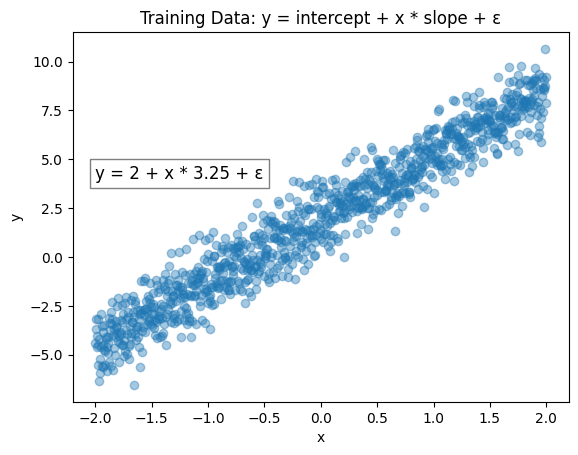

In [6]:
# Generate dependent variable y as a function of the training data x, the desired slope, and the desired intercept
#y_train = np.add(np.add(np.dot(x_train[:,1], desired_slope) ,desired_intercept), np.random.randn(num_training_samples))#[:, np.newaxis]
y_train = desired_intercept + x_train * desired_slope + np.random.randn(num_training_samples)[:, np.newaxis]
# Print the shape of x_train and y_train
print('x_train shape:', x_train.shape)
print('y_train shape:', y_train.shape)
# Plot the training data (ignoring the intercept term in each entry of x_train)
#plt.scatter(x_train[:,1], y_train, alpha=0.4)
plt.scatter(x_train, y_train, alpha=0.4)
plt.title('Training Data: y = intercept + x * slope + \u03B5')
plt.xlabel('x')
plt.ylabel('y')
plt.text(-2., 4, f'y = {desired_intercept} + x * {desired_slope} + \u03B5',
                       fontsize=12, bbox=dict(facecolor='white', alpha=0.5, edgecolor='black')) 
plt.show()


<H1>2) Configure the linear regression model</H1>

Let $n$ be the number of training samples and $m$ be the number of features in the training data.

$$\large\underset{\left(nx1\right)}{Y}=\begin{pmatrix}
y_{0} \\
y_{1} \\
\vdots \\
y_{n-1} \end{pmatrix}, 

\quad\underset{\left(nxm\right)}{X}=\left[\begin{matrix}
x_{0,0}=1 & x_{0,11} &\dots &x_{0,m-1} \\
x_{1,0}=1 & x_{1,1} &\dots &x_{1,m-1} \\
\vdots & \dots & \ddots & \vdots\\
x_{n-1,0}=1 & \dots & \dots &x_{N-1, m-1}
\end{matrix}\right],

\quad\underset{\left(Nx1\right)}{\epsilon}=\begin{pmatrix}
\epsilon_{0} \\
\epsilon_{1} \\
\vdots \\
\epsilon_{n-1} \end{pmatrix}
\text{where }\epsilon\sim\mathcal{N}\left(0, \sigma^{2}I\right)$$

$$\large\hat{Y}\sim\mathcal{N}(\hat{\beta} X, \hat{\sigma}^{2}I)$$


$$\large\beta=\begin{pmatrix}
\beta_{0} \\
\beta_{1} \\
\vdots \\
\beta_{m} \end{pmatrix}$$
$$\large\hat{Y}=X\hat{\beta}$$

<H1>References</H1>

1. Gelman A., Carlin J., Stern H., Dunson D., Vehtari A., Rubin D., "Bayesian Data Analysis", CRC Press, Boca Raton FL, 3rd ed., 2014.